In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
import pandas as pd
%matplotlib.inline

UsageError: Line magic function `%matplotlib.inline` not found.


In [3]:
X,y=make_blobs(n_samples=1000,centers=3,n_features=2)


In [4]:
X

array([[-11.36908504,  -5.56045364],
       [ -4.29982182,  -7.72823027],
       [ -2.48955555,   4.10390648],
       ...,
       [ -3.19372005,  -7.13641033],
       [ -3.94040737,  -6.05406061],
       [ -2.68729788,  -8.27617331]], shape=(1000, 2))

In [5]:
y

array([1, 2, 0, 0, 0, 2, 1, 2, 0, 1, 1, 2, 2, 2, 0, 1, 1, 1, 1, 2, 1, 0,
       0, 2, 2, 2, 0, 1, 0, 0, 1, 0, 1, 0, 1, 0, 0, 1, 1, 0, 1, 1, 2, 1,
       1, 1, 1, 0, 2, 2, 2, 2, 2, 0, 0, 2, 1, 2, 0, 2, 1, 2, 1, 2, 1, 2,
       0, 2, 0, 2, 0, 2, 1, 0, 2, 2, 0, 1, 0, 1, 1, 1, 2, 1, 0, 2, 0, 2,
       2, 2, 1, 1, 1, 0, 1, 2, 1, 2, 1, 2, 0, 1, 2, 2, 0, 0, 2, 0, 2, 0,
       0, 1, 0, 0, 1, 2, 0, 1, 0, 1, 1, 2, 2, 1, 0, 2, 0, 1, 2, 2, 1, 1,
       1, 0, 2, 1, 1, 1, 0, 2, 1, 1, 0, 2, 0, 1, 2, 0, 0, 1, 0, 1, 2, 0,
       1, 2, 1, 2, 0, 1, 0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 2, 2, 1, 2, 2, 1,
       0, 0, 0, 2, 1, 1, 2, 0, 2, 0, 2, 1, 2, 2, 0, 0, 0, 0, 1, 2, 1, 0,
       0, 0, 0, 1, 0, 1, 1, 1, 2, 2, 1, 0, 2, 1, 2, 1, 1, 1, 1, 2, 0, 2,
       2, 0, 0, 2, 0, 1, 2, 1, 1, 0, 0, 2, 1, 0, 0, 0, 1, 1, 2, 2, 1, 0,
       0, 2, 2, 0, 0, 1, 1, 1, 0, 2, 0, 0, 2, 0, 0, 1, 2, 0, 0, 0, 1, 2,
       0, 2, 2, 1, 1, 0, 0, 0, 2, 1, 2, 1, 2, 1, 1, 0, 1, 2, 0, 1, 2, 1,
       2, 2, 0, 0, 1, 1, 1, 0, 0, 0, 1, 1, 1, 2, 2,

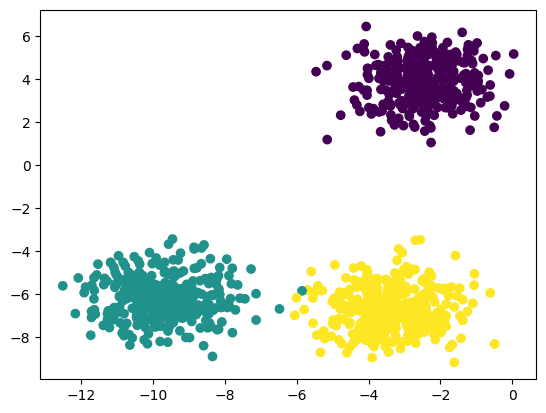

In [7]:
plt.scatter(X[:,0],X[:,1],c=y)

In [8]:
## Standardization feature scaling

from sklearn.preprocessing import StandardScaler
scalar=StandardScaler()

In [9]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.33, random_state=42)

In [13]:
X_train_scaled=scalar.fit_transform(X_train)

In [14]:
X_test_scaled=scalar.transform(X_test)

In [15]:
from sklearn.cluster import KMeans

In [16]:
## Elbow Method to select k value

wcss=[]
for k in range(1,11):
  kmeans=KMeans(n_clusters=k,init="k-means++")
  kmeans.fit(X_train_scaled)
  wcss.append(kmeans.inertia_)

In [17]:
wcss

[1340.0,
 472.4067241607056,
 87.6523353239751,
 76.22786784094885,
 58.78317425981636,
 47.41755176505487,
 43.54432423658939,
 40.89400076377917,
 38.256488661110716,
 33.79646918849362]

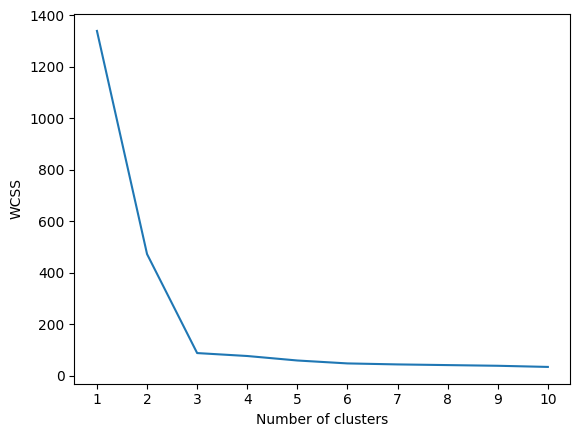

In [18]:
## plot elbow curve
plt.plot(range(1,11),wcss)
plt.xticks(range(1,11))
plt.xlabel("Number of clusters")
plt.ylabel("WCSS")
plt.show()